In [25]:
import pandas as pd
import numpy as np
import string
import re
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

In [9]:
### The given dataset is tsv file which means it has Tab -separated Values

In [34]:
df=pd.read_csv('amazonreviews.tsv',sep='\t')
df.head(3)

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [12]:
df.shape

(10000, 2)

In [13]:
### Checking for missing values and duplicates
df.isnull().sum()

label     0
review    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

### There are no missing values and duplicate values in the given dataset

In [15]:
!pip install nltk

In [16]:
# now importing NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wasi2\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\wasi2\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\wasi2\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [17]:
# Text Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)


df['clean_review'] = df['review'].apply(clean_text)

#### 2.Exploratory Analysis: Word clouds, sentiment distribution, most common positive/negative words.

In [18]:
!pip install wordcloud

In [19]:
# Importing Visualization libraries 
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [20]:
#  Checking for the Sentiment Distribution within the dataset
print(df['label'].value_counts()) 

label
neg    5097
pos    4903
Name: count, dtype: int64


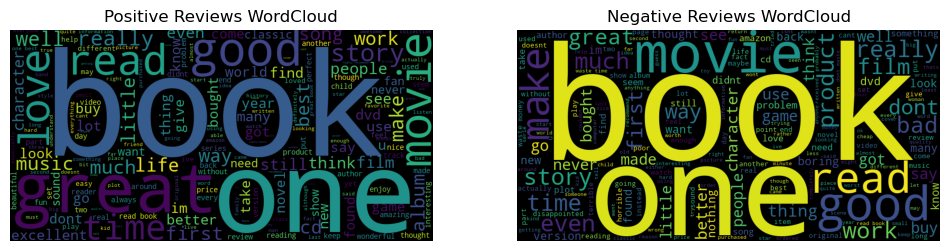

In [21]:
# WordClouds
pos_text = ' '.join(df[df['label']=='pos']['clean_review'])
neg_text = ' '.join(df[df['label']=='neg']['clean_review'])

wc_pos = WordCloud(width=800, height=400).generate(pos_text)
wc_neg = WordCloud(width=800, height=400).generate(neg_text)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(wc_pos)
plt.title('Positive Reviews WordCloud')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(wc_neg)
plt.title('Negative Reviews WordCloud')
plt.axis('off')
plt.show()

#### Model Development: Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks

In [23]:
#calculating metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [24]:
# 4. Feature Engineering (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer
X = df['clean_review']
y = df['label'].map({'pos':1, 'neg':0})

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

In [26]:
### Train test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
# Logistic Regression Model Training
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [28]:
 # SVM Model Training 
from sklearn.svm import LinearSVC
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

LinearSVC()

In [29]:
# Evaluation
# Getting the metric calculation using Logistic Regression model
lr_pred = lr_model.predict(X_test)
print("\n--- Logistic Regression Results ---")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# Getting the calculation metrics using SVM model
svm_pred = svm_model.predict(X_test)
print("\n--- SVM Results ---")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("F1 Score:", f1_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


--- Logistic Regression Results ---
Accuracy: 0.8485
F1 Score: 0.8450127877237852
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1019
           1       0.85      0.84      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


--- SVM Results ---
Accuracy: 0.8345
F1 Score: 0.8320649416539827
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1019
           1       0.83      0.84      0.83       981

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



#### Validation: Use train/test split, cross-validation, and metrics like accuracy, F1-scorem

In [32]:
from sklearn.model_selection import cross_val_score
accuracy_scores = cross_val_score(lr_model, X_tfidf, y, cv=5, scoring='accuracy')

# F1-score (weighted for balanced evaluation)
f1_scores = cross_val_score(lr_model, X_tfidf, y, cv=5, scoring='f1_weighted')

print("Cross Validation Accuracy of Linear Regression:", accuracy_scores)
print("Mean Accuracy:", accuracy_scores.mean())

print("\nCross Validation F1 Scores of Linear Regression:", f1_scores)
print("Mean F1 Score:", f1_scores.mean())

Cross Validation Accuracy of Linear Regression: [0.8495 0.8255 0.8175 0.8245 0.848 ]
Mean Accuracy: 0.833

Cross Validation F1 Scores of Linear Regression: [0.84950817 0.82545272 0.81730513 0.82451716 0.84801383]
Mean F1 Score: 0.8329594009787453


In [33]:
accuracy_scores = cross_val_score(svm_model, X_tfidf, y, cv=5, scoring='accuracy')

# F1-score (weighted for balanced evaluation)
f1_scores = cross_val_score(svm_model, X_tfidf, y, cv=5, scoring='f1_weighted')

print("Cross Validation Accuracy of SVM:", accuracy_scores)
print("Mean Accuracy:", accuracy_scores.mean())

print("\nCross Validation F1 Scores of SVM:", f1_scores)
print("Mean F1 Score:", f1_scores.mean())

Cross Validation Accuracy of SVM: [0.85   0.813  0.8085 0.8205 0.838 ]
Mean Accuracy: 0.826

Cross Validation F1 Scores of SVM: [0.8499901  0.81301309 0.80840687 0.82051791 0.83801604]
Mean F1 Score: 0.8259888017637789
